In [1]:
import numpy as np
import matplotlib.pyplot as plt

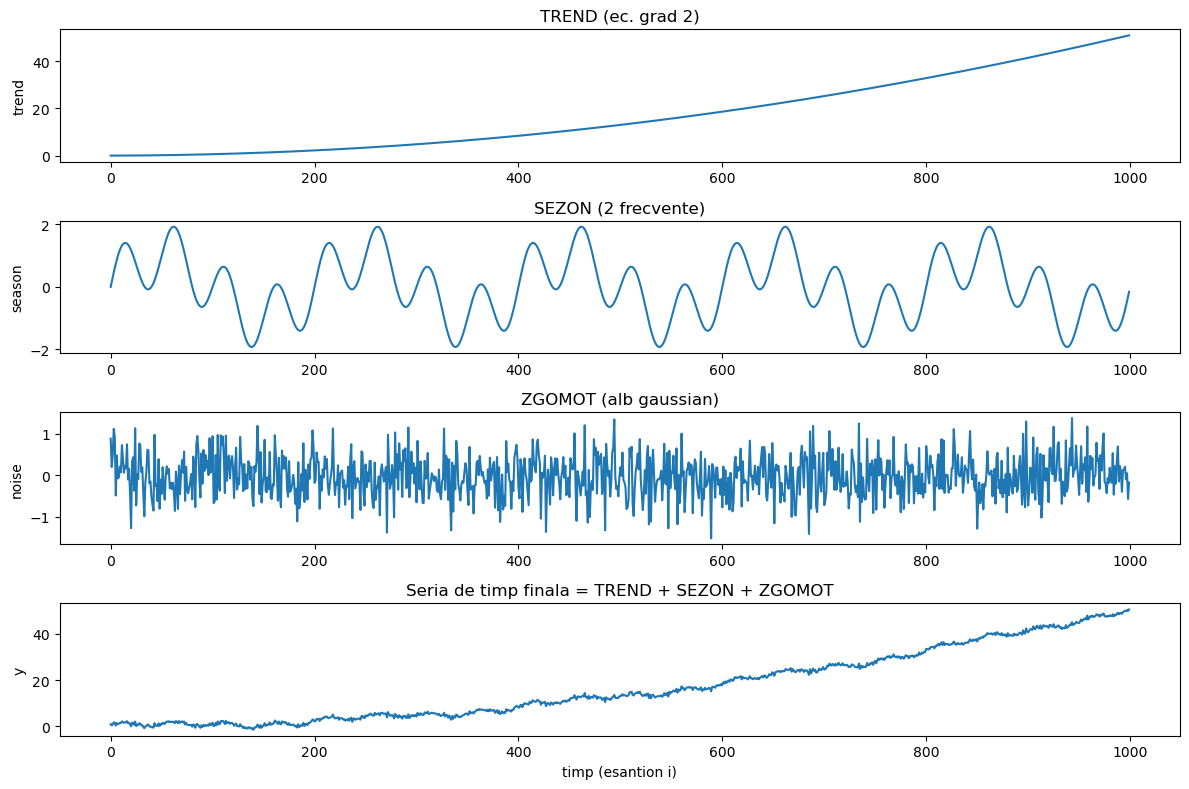

In [2]:
#1 IMPORT DIN LAB 8 - COD PT GENERARE SERIE TIMP CU 3 COMPONENTE

# generez o serie de timp N=1000 ca suma a trei componente:

# trend = o ec de gr 2
# sezon = 2 frecvente
# variatiile mici = zgomot alb gaussian

# Desenez seria de timp si cele 3 componente separat

N = 1000
t = np.arange(N) #momentele de timp 0, 1, ..., 999

# TREND (polinom de grad 2)
a, b, c = 0.00005, 1e-3, 0
trend = a * t ** 2 + b * t + c

#  SEZON
T1 = 50 # din 50 in 50 de esantioane
f1 = 1/T1
T2 = 200 # din 200 in 200
f2 = 1/T2
season =  np.sin(2 * np.pi *f1* t) + np.sin(2 * np.pi * f2*t )

# ZGOMOT
np.random.seed(0)   # ca să iasă la fel de fiecare dată
sigma = 0.5
noise = np.random.normal(0, sigma, size=N)

# SERIA DE TIMP = TREND + SESON + ZGOMOT
y = trend + season + noise

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, trend)
plt.title("TREND (ec. grad 2)")
plt.ylabel("trend")

plt.subplot(4, 1, 2)
plt.plot(t, season)
plt.title("SEZON (2 frecvente)")
plt.ylabel("season")

plt.subplot(4, 1, 3)
plt.plot(t, noise)
plt.title("ZGOMOT (alb gaussian)")
plt.ylabel("noise")

plt.subplot(4, 1, 4)
plt.plot(t, y)
plt.title("Seria de timp finala = TREND + SEZON + ZGOMOT")
plt.ylabel("y")
plt.xlabel("timp (esantion i)")

plt.tight_layout()
plt.savefig("1 Seria de timp.pdf")
plt.show()

In [ ]:
# 2
# Pentru seria de timp generata mai sus, y, calculez noua serie de timp rezultata din medierea exponentiala

# initial fixez alpha, apoi caut un alpha cat mai bun

# estimez seria apoi si cu:
# -mediere exp dubla
# -mediere exp tripla

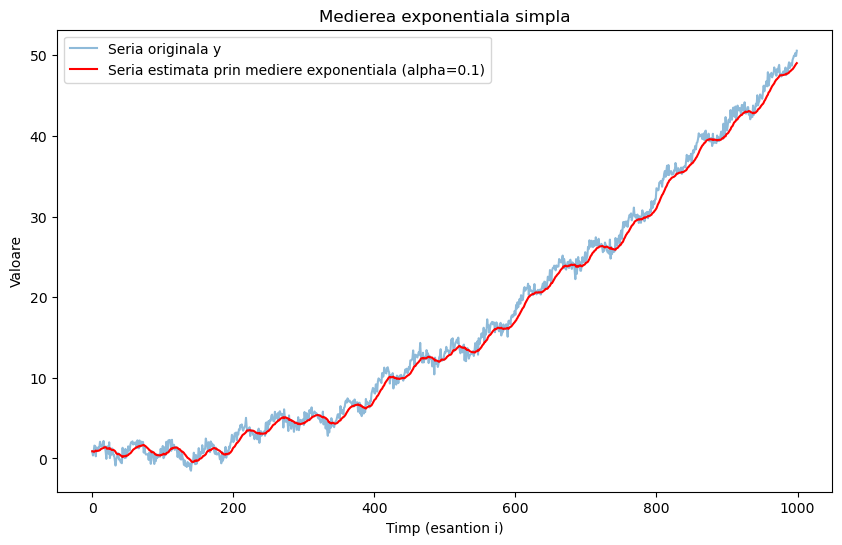

In [3]:
# Serie rezultata din mediere exponentiala - alpha fixat
# y = seria de mai sus

alpha = 0.1

N = len(y)
s = np.zeros(N)
s[0] = y[0]  
for i in range(1, N):
    s[i] = alpha * y[i] + (1 - alpha) * s[i - 1]


#Predictia:

y_hat = np.zeros(N)
y_hat[0] = s[0]
y_hat[1:] = s[0:N-1]      # predictia pt momentul i este s[i-1]

plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat, label=f"Seria estimata prin mediere exponentiala (alpha={alpha})", color='red')
plt.title("Medierea exponentiala simpla")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2a Mediere exponentiala simpla alpha = 0.1.pdf")
plt.show()



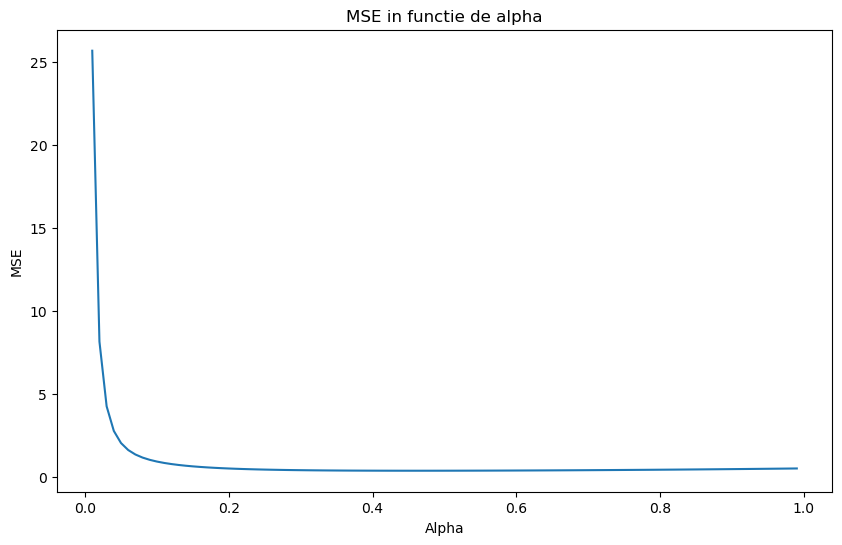

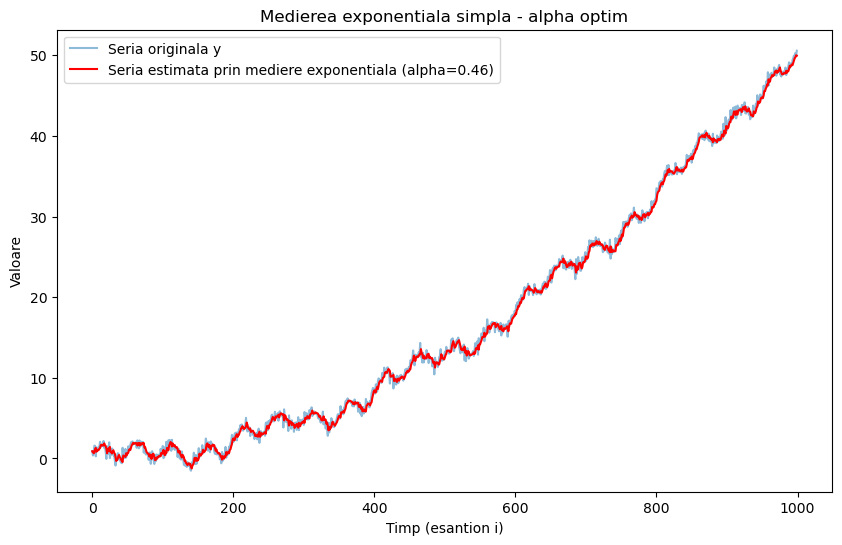

In [ ]:
# Mediere exp simpla, dar caut alpha optim!

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

dic_alpha_and_mse = {}

best_alpha = None
best_mse = float('inf')

for alpha in np.arange(0.01, 1.0, 0.01): #caut alpha optim in intervalul 0.01 -> 0.99 cu pasul 0.01
    s = np.zeros(N)
    s[0] = y[0]  
    for i in range(1, N):
        s[i] = alpha * y[i] + (1 - alpha) * s[i - 1]
    
    y_hat = np.zeros(N)
    y_hat[0] = s[0]
    y_hat[1:] = s[0:N-1]
    
    current_mse = mse(y, y_hat)
    
    if current_mse < best_mse:
        best_mse = current_mse
        best_alpha = alpha
        
    dic_alpha_and_mse[alpha] = current_mse
    
#alpha vs mse
plt.figure(figsize=(10, 6))
plt.plot(list(dic_alpha_and_mse.keys()), list(dic_alpha_and_mse.values()))
plt.title("MSE in functie de alpha")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.savefig("2b MSE vs alpha.pdf")


#seria reconstruita cu cel mai bun alpha:

s = np.zeros(N)
s[0] = y[0]
for i in range(1, N):
    s[i] = best_alpha * y[i] + (1 - best_alpha) * s[i - 1]
y_hat = np.zeros(N)
y_hat[0] = s[0]    
y_hat[1:] = s[0:N-1]
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat, label=f"Seria estimata prin mediere exponentiala (alpha={best_alpha:.2f})", color='red')
plt.title("Medierea exponentiala simpla - alpha optim")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2c Mediere exponentiala simpla alpha optim.pdf")



        

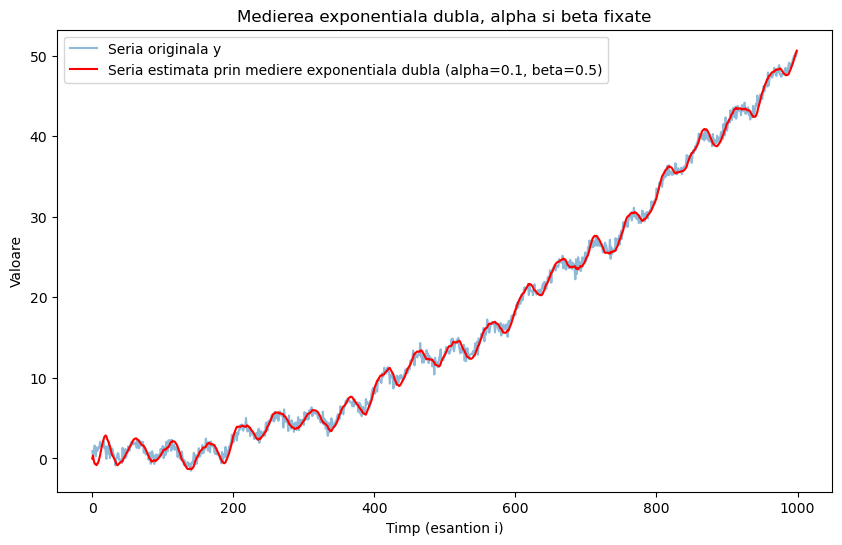

In [11]:
# Repet experimentul pentru mediere exponentiala dubla
#-alpha, betta alese
#-apoi cautat optimul pt alpha si betta

# y = seria reala, originala

#1. alpha, betta setate de mine:

alpha = 0.1
beta = 0.5

N = len(y)
s = np.zeros(N)
b = np.zeros(N)

s[0] = y[0]
b[0] = y[1] - y[0]

for t in range(1, N):
    s[t] = alpha * y[t] + (1 - alpha) * (s[t - 1] + b[t - 1])
    b[t] = beta * (s[t] - s[t - 1]) + (1 - beta) * b[t - 1]

y_hat = np.zeros(N)
m = 1  # pentru predictia cu un pas in viitor
for t in range(0, N-1):
    y_hat[t+m] = s[t] + m * b[t]
    
t = np.arange(N) #momentele de timp
    
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat, label=f"Seria estimata prin mediere exponentiala dubla (alpha={alpha}, beta={beta})", color='red')
plt.title("Medierea exponentiala dubla, alpha si beta fixate")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2d Mediere exponentiala dubla alpha=0.1 beta=0.1.pdf")
plt.show()

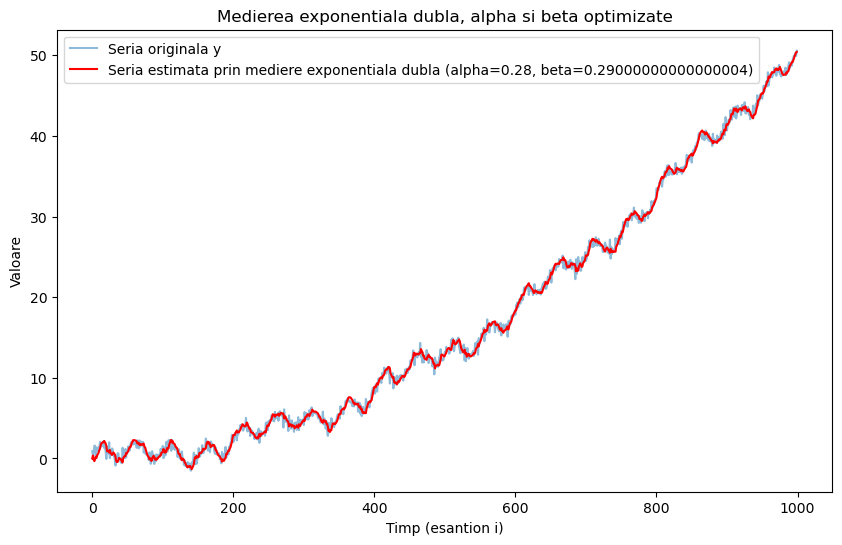

In [13]:
#2. alpha, betta pentru care caut valorile optime intre 0 si 1:

alphas = np.arange(0.01, 1.0, 0.01)
betas = np.arange(0.01, 1.0, 0.01)

dic_alpha_beta_and_mse = {}
best_mse = np.inf
best_alpha = None
best_beta = None
y_hat_giving_best_mse = None

N = len(y)
s = np.zeros(N)
b = np.zeros(N)

s[0] = y[0]
b[0] = y[1] - y[0]

for alpha in alphas: #incerc toate perechile de (alpha, beta) pentru a o gasi pe cea care minimizeaza MSE
    for beta in betas:
        for t in range(1, N):
            s[t] = alpha * y[t] + (1 - alpha) * (s[t - 1] + b[t - 1])
            b[t] = beta * (s[t] - s[t - 1]) + (1 - beta) * b[t - 1]

        y_hat = np.zeros(N)
        m = 1  # pentru predictia cu un pas in viitor
        for t in range(0, N-1):
            y_hat[t+m] = s[t] + m * b[t]
        
        current_mse = mse(y, y_hat)
        dic_alpha_beta_and_mse[(alpha, beta)] = current_mse
        
        if current_mse < best_mse:
            best_mse = current_mse
            best_alpha = alpha
            best_beta = beta
            y_hat_giving_best_mse = y_hat.copy()
    
t = np.arange(N) #momentele de timp
    
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat_giving_best_mse, label=f"Seria estimata prin mediere exponentiala dubla (alpha={best_alpha}, beta={best_beta})", color='red')
plt.title("Medierea exponentiala dubla, alpha si beta optimizate")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2e Mediere exponentiala dubla alpha beta optime.pdf")
plt.show()

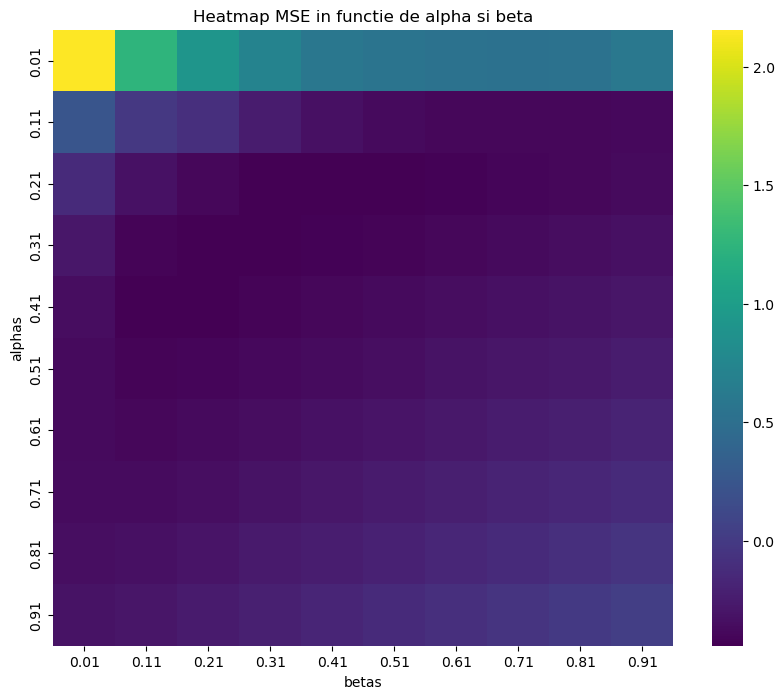

In [19]:
#heatmap pt alpha, beta vs mse
alphas = np.arange(0.01, 1.0, 0.01)
betas = np.arange(0.01, 1.0, 0.01)

alphas = alphas[::10] #le iau mai rare pentru a putea reprezenta axele Ox si Oy mai aerisit
betas  = betas[::10]

mse_values = np.zeros((len(alphas), len(betas)))
for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        mse_values[i, j] = dic_alpha_beta_and_mse[(alpha, beta)]

mse_log = np.log10(mse_values + 1e-8) #reprezint pe scara logaritmica, ca sa se vada mai bine diferentele mici

import seaborn as sns
plt.figure(figsize=(10, 8)) 
sns.heatmap(mse_log, xticklabels=np.round(betas,2), yticklabels=np.round(alphas,2), cmap="viridis")
plt.title("Heatmap MSE in functie de alpha si beta")
plt.ylabel("alphas")
plt.xlabel("betas")
plt.savefig("2f Heatmap mediere exp dubla - MSE vs alpha beta.pdf")

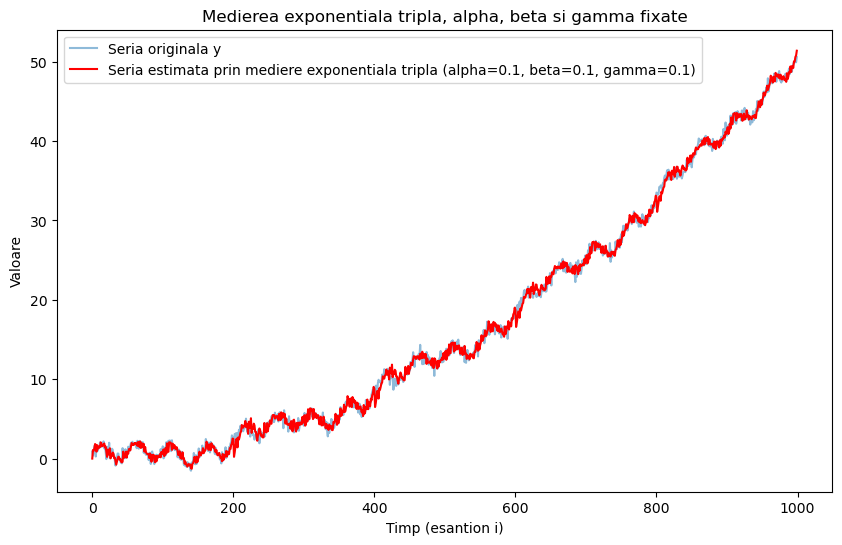

In [ ]:
# Repet experimentul pentru medierea exponentiala tripla
# 1. alpha, beta, gamma setate de mine

#caz a: sezonalitate aditiva 
#doar acest caz are sens pentru cum am construit eu y

#componenta mea sezoniera are 2 perioade: 50 si 200. Ca sa le prind pe ambele, aleg L = 200
L = 200

alpha = 0.1
beta = 0.1
gamma = 0.1

N = len(y)
s = np.zeros(N) #nivel
b = np.zeros(N) #trend
c = np.zeros(N) #sezon

s[0] = y[0]  
b[0] = y[1] - y[0]

for i in range(L):
    c[i] = y[i] - s[i]  #initializare comp. sezoniera
                            # primele L valori sunt abaterea de la nivel, adica de la s[i]
                            
                    # s[i]/s[0] ????? s[i] merge mai bine


for t in range(L, N):
    s[t] = alpha*(y[t] - c[t - L]) + (1 - alpha)*(s[t - 1] + b[t - 1])
    b[t] = beta*(s[t] - s[t - 1]) + (1 - beta)*b[t - 1]
    c[t] = gamma * (y[t] - s[t] - b[t-1]) + (1 - gamma) * c[t - L]


y_hat = np.zeros(N)
m = 1  # pentru predictia cu un pas in viitor
for t in range(0, N-1):
    y_hat[t+m] = s[t] + m * b[t] + c[t - L + ((m - 1) % L)]
    
t = np.arange(N) #momentele de timp
    
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat, label=f"Seria estimata prin mediere exponentiala tripla (alpha={alpha}, beta={beta}, gamma={gamma})", color='red')
plt.title("Medierea exponentiala tripla, alpha, beta si gamma fixate")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2g Mediere exponentiala tripla alpha=0.1 beta=0.1 gamma=0.1.pdf")
plt.show()

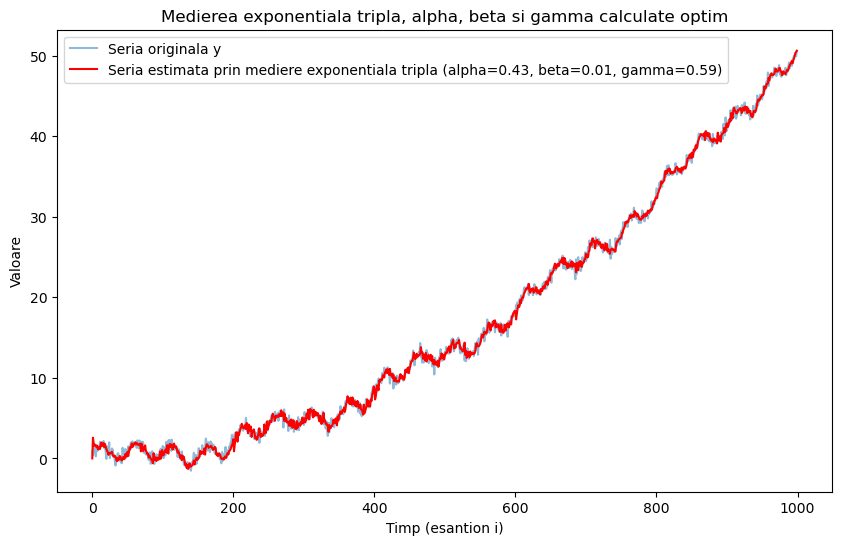

In [22]:
# Repet experimentul pentru medierea exponentiala tripla
# 2. alpha, beta, gamma cautate optim

#caz a: sezonalitate aditiva


L = 200

alphas = np.arange(0.01, 1.0, 0.01)
betas = np.arange(0.01, 1.0, 0.01)
gammas = np.arange(0.01, 1.0, 0.01)

best_alpha = None
best_beta = None
best_gamma = None

best_mse = float('inf')
y_hat_giving_best_mse = None    

for alpha in alphas:
    for beta in betas:
        for gamma in gammas:
            N = len(y)
            s = np.zeros(N) #nivel
            b = np.zeros(N) #trend
            c = np.zeros(N) #sezon

            s[0] = y[0]  
            b[0] = y[1] - y[0]

            for i in range(L):
                c[i] = y[i] - s[i]  #initializare comp. sezoniera
                                        # primele L valori sunt abaterea de la nivel, adica de la s[i]=0

            for t in range(L, N):
                s[t] = alpha*(y[t] - c[t - L]) + (1 - alpha)*(s[t - 1] + b[t - 1])
                b[t] = beta*(s[t] - s[t - 1]) + (1 - beta)*b[t - 1]
                c[t] = gamma * (y[t] - s[t] - b[t-1]) + (1 - gamma) * c[t - L]


            y_hat = np.zeros(N)
            m = 1  # pentru predictia cu un pas in viitor
            for t in range(0, N-1):
                y_hat[t+m] = s[t] + m * b[t] + c[t - L + ((m - 1) % L)]
            
            current_mse = mse(y[L:], y_hat[L:])  #compar doar de la L incolo, ca sa evit faza de initializare
            if current_mse < best_mse:
                best_mse = current_mse
                best_alpha = alpha
                best_beta = beta
                best_gamma = gamma
                y_hat_giving_best_mse = y_hat.copy()

    
t = np.arange(N) #momentele de timp
    
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Seria originala y", alpha=0.5)
plt.plot(t, y_hat_giving_best_mse, label=f"Seria estimata prin mediere exponentiala tripla (alpha={best_alpha}, beta={best_beta}, gamma={best_gamma})", color='red')
plt.title("Medierea exponentiala tripla, alpha, beta si gamma calculate optim")
plt.ylabel("Valoare")
plt.xlabel("Timp (esantion i)")
plt.legend()
plt.savefig("2h Mediere exponentiala tripla alpha,beta,gamma optime.pdf")
plt.show()



q=200, theta=[-0.008  0.018  0.12   0.036  0.041  0.054  0.141  0.022  0.04  -0.064
  0.016  0.005  0.077  0.054  0.06   0.065  0.116 -0.018  0.033 -0.008
  0.075  0.028  0.005 -0.01   0.028  0.056  0.04   0.019  0.075 -0.025
  0.007 -0.047  0.009 -0.038  0.058 -0.027  0.004 -0.085  0.099  0.065
  0.003 -0.035  0.062  0.042  0.074  0.04  -0.027  0.028  0.031 -0.038
  0.046 -0.08   0.01  -0.018  0.057 -0.009  0.041  0.018  0.087 -0.02
 -0.075 -0.076  0.065 -0.021  0.005 -0.021  0.029 -0.048 -0.069 -0.162
 -0.075 -0.072  0.003 -0.033 -0.002  0.007  0.045  0.004 -0.014 -0.05
  0.061 -0.062 -0.026 -0.087 -0.    -0.004  0.031 -0.052 -0.053 -0.033
  0.093 -0.049 -0.    -0.041  0.034  0.009  0.061 -0.019 -0.003 -0.036
  0.036 -0.075  0.037 -0.025  0.034 -0.028 -0.001 -0.087 -0.03   0.029
 -0.009  0.034  0.012  0.057  0.064  0.016 -0.03   0.014 -0.003 -0.035
  0.006 -0.027 -0.002  0.023  0.031  0.03   0.031  0.066  0.098  0.017
  0.02  -0.035 -0.053  0.017  0.082  0.063  0.094  0.012 -0.032 -0

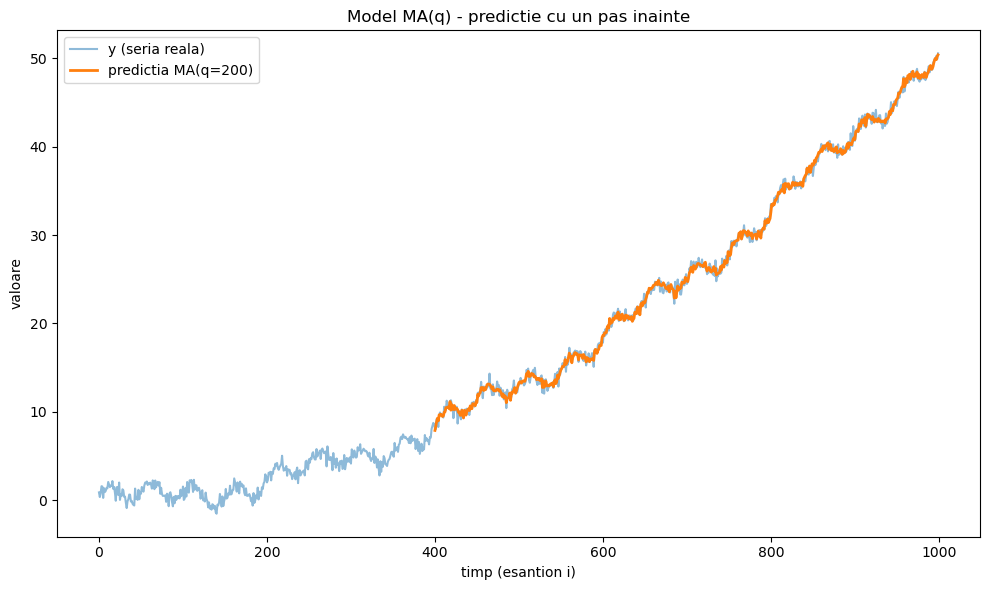

In [ ]:
# 3. un model MA(q) (medie alunecatoare/moving average) pentru seria y generata la inceput
# termenii de eroare ϵ[i] sunt deviatia de la media calculata de mine anterior pentru fiecare orizont de calcul 

# Pentru fiecare moment i:
#       calculez media ultimilor q pasi (med_q[i])
#       calculez eroarea epsilon[i] = y[i] - med_q[i]

# y_hat = med_q[i] + theta_1 * ϵ[i-1] + ... + theta_q * ϵ[i-q]


def fit_ma_q(y, q): #functie care gaseste parametrii thetha optimi ai modelului MA(q)
    
    N = len(y)

    med_q = np.full(N, np.nan) # vectorul in car stochez mediile pe ultimii q pasi, pt fiecare pozitie curenta i
    for i in range(q, N):
        med_q[i] = np.mean(y[i-q:i])

    eps = np.full(N, np.nan) # eroarea = deviatia fata de media pe orizontul local q
    for i in range(q, N):
        eps[i] = y[i] - med_q[i]

    #vreau ca eroarea curenta sa fie explicata cat mai bine de erorile trecute
    #adica: eps[i] = theta_1 * eps[i-1] + ... + theta_q * eps[i-q]
    
    #vreau ca erorile seriei de timp sa prezinte corelatie pe orizontul de timp q, iar modelul MA(q) sa descrie astfel aceasta dependenta exprimand
    #eroarea curenta ca o combinatie liniara a erorilor anterioare pe orizontul q
    
    #construiesc sistemul:  A * theta = b, unde:
    #A = matricea cu erorile trecute, q erori pe fiecare linie: eps[i-1], eps[i-2], ..., eps[i-q]
    #b = vectorul cu erorile curente:                            eps[i], eps[i+1], ...
    
    #Concret:
    # b[i] = y[i] - med_q[i] = eps[i]
    # A[i, k-1] = eps[i-k]
    
    A = []
    b = []

    #ca sa existe eps[i] = y[i] - med_q[i], trebuie sa existe med_q[i] = mean(y[i-q, i]), deci i >= q
    #de asemenea, 
    # ca sa existe eps[i] = theta_1 * eps[i-1] + ... + theta_q * eps[i-q], trebuie sa existe eps[i-q], deci tb sa existe med_q[i-q], deci i-q >= q  => i >= 2q

    for i in range(2*q, N):  # ca sa existe eps[i-1,..,i-q] (sa nu fie nan)
        A.append([eps[i-k] for k in range(1, q+1)])
        b.append(eps[i])

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    # rezolv sistemul cu least squares, adica incerc sa minimizez cu theta ||A*theta - b||^2
    theta, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

    return theta, med_q, eps

def predict_ma_q(y, q, theta, med_q, eps): #functia care face predictia valorii urmatoare din serie folosind modelul MA(q)

    N = len(y)
    y_hat = np.full(N, np.nan)

    for i in range(2*q, N):
        #predictia = med_q[i] + theta_1 * eps[i-1] + ... + theta_q * eps[i-q], dar eps[i-q] exista doar de la i-q >= q => i >= 2q
        y_hat[i] =np.dot(theta, [eps[i-k] for k in range(1, q+1)]) + med_q[i]

    return y_hat

# Predictia concreta:
q = 200  #orizontul

theta, med_q, eps = fit_ma_q(y, q)
y_hat = predict_ma_q(y, q, theta, med_q, eps)

# MSE (ignor primele valori din y_hat care sunt nan)
mse = np.mean((y_hat[2*q:] - y[2*q:])**2)

print(f"q={q}, theta={np.round(theta,3)}")
print(f"MSE={mse:.4f}")

t = np.arange(len(y))
plt.figure(figsize=(10,6))
plt.plot(t, y, label="y (seria reala)", alpha=0.5)
plt.plot(t, y_hat, label=f"predictia MA(q={q})", linewidth=2)
plt.title("Model MA(q) - predictie cu un pas inainte")
plt.xlabel("timp (esantion i)")
plt.ylabel("valoare")
plt.legend()
plt.tight_layout()
plt.savefig("3 Model MA(q).pdf")
plt.show()

#Obs:
# q = 10 => MSE = 0.3353
# q = 20 => MSE = 0.3274
# q = 40 => MSE = 0.2880
# q = 60 => MSE = 0.2730
# q = 80 => MSE = 0.2577
# q = 100 => MSE = 0.2383
# q = 200 => MSE = 0.1830
# q = 300 => MSE = 0.0744
# q = 400 => MSE = 0

# ! q mare => predictie mai buna

c:\Users\crist\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\crist\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\crist\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\crist\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\crist\anaconda3\Lib\site-packages\statsmodels\base\model

Cel mai bun model ARMA(p,q): p=1, q=5


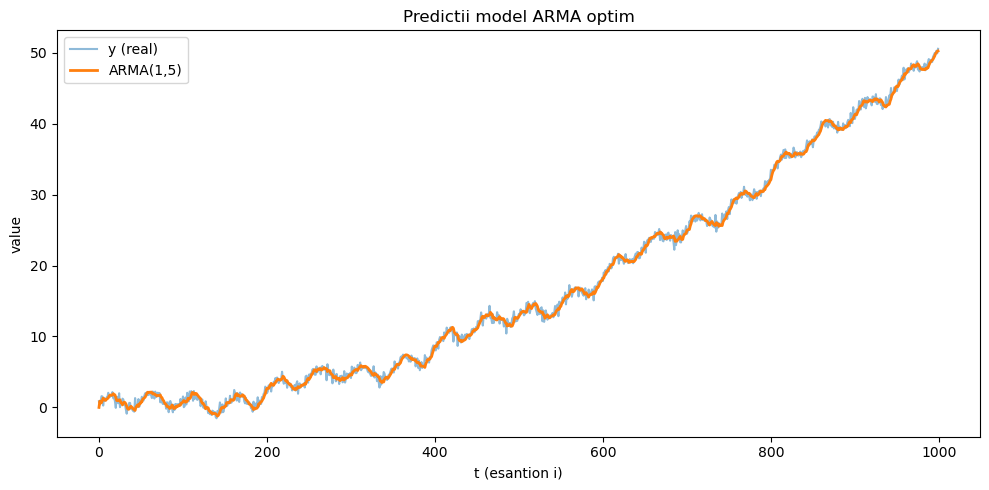

In [ ]:
# 4 un model ARMA cu orizont p si q pentru seria y generata la inceput
# termenii de eroare ϵ[i] sunt deviatia de la media calculata de mine anterior pentru fiecare orizont de calcul

# calculez parametrii optimi p si q cu o limita de 20 pentru fiecare
import scipy
from statsmodels.tsa.arima.model import ARIMA

best_aic = np.inf
best_order = None
best_model = None

for p in range(1, 10): #ruleaza >10 ore pentru p,q pana la 20 :((
    for q in range(1, 10):

        try:
            model = ARIMA(y, order=(p, 1, q)) # pun d = 1 pt ca seria nu e stationara/ are trend
            result = model.fit()

            if not result.mle_retvals.get("converged", True): #sar peste modelele care nu converg
                continue

            if result.aic < best_aic: #akaike information criterion = scor care descrie calitatea modelului, trade-off intre cat de bine se potriveste modelul pe date si complexitatea modelului (nr de param)
                best_aic = result.aic
                best_order = (p, q)
                best_model = result

        except Exception:
            continue


print(f"Cel mai bun model ARMA(p,q): p={best_order[0]}, q={best_order[1]}")

y_hat = best_model.predict(start=0, end=len(y)-1)
t = np.arange(len(y))

plt.figure(figsize=(10,5))
plt.plot(t, y, label="y (real)", alpha=0.5)
plt.plot(t, y_hat, label=f"ARMA({best_order[0]},{best_order[1]})", linewidth=2)
plt.title("Predictii model ARMA optim")
plt.xlabel("t (esantion i)")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.savefig("4 Model ARMA(p,q) optim.pdf")
plt.show()

